# Testando um modelo simples de aprendizado de um Datase aleatório

## Imports

In [1]:
import IPython.display as ipd
import json
import numpy as np
import matplotlib.pyplot as plt
import random
import soundfile as sf
import pandas as pd

from fm_synth import FMSynth, SAMPLE_RATE


## Gerando um dataset aleatório

### Rodando aleatoriamente e salvando o resultado

In [2]:
duracao_amostras = 4
tamanho_dataset = 5000
precisao_decimal = 3
base_path = 'dataset_big2'

## Lendo o dataset no formato pandas

### Lendo as variáveis de entrada

In [3]:
samples = []
for i in range(tamanho_dataset):
    signal = sf.read(f"{base_path}/sample_{i+1}.wav")
    samples.append(signal)

samples = pd.DataFrame(samples)

In [4]:
samples = samples.drop(columns=[1])
samples.head()

,0
0,"[-3.0517578125e-05, 0.0, 0.0, 3.0517578125e-05..."
1,"[-3.0517578125e-05, 0.0, 9.1552734375e-05, 0.0..."
2,"[-3.0517578125e-05, 0.0, 6.103515625e-05, 0.00..."
3,"[-3.0517578125e-05, 0.0, 0.0, 0.0, 0.0, 3.0517..."
4,"[-3.0517578125e-05, 0.0, 0.0, 0.0, 3.051757812..."


### Lendo o alvo

In [5]:
with open(f"{base_path}/parameters.json", "r") as f:
    target = f.read()

target = json.loads(target)
target = target[:tamanho_dataset]

target = pd.DataFrame(target)
target.head()

,id,frequencia_base,frequency1,beta2,frequency2,beta3,frequency3,beta4,frequency4,beta5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,1,33.972,0.167,4.101,3.000,2.078,5.000,0.000,1.500,2.812,0.167,8.000,0.769,0.113,0.426,0.774,0.375
1,2,309.502,3.000,1.829,1.000,1.443,1.000,0.610,5.000,0.000,0.667,3.941,0.969,0.158,0.235,0.332,0.422
2,3,394.895,4.000,1.619,1.500,0.000,0.125,1.001,0.250,4.914,1.500,0.158,0.720,0.365,0.510,0.407,0.722
3,4,30.844,0.125,2.717,0.486,2.273,5.000,0.000,2.000,0.000,0.667,3.433,0.799,0.322,0.329,0.749,0.446
4,5,55.182,2.000,2.455,8.000,0.000,0.167,0.000,0.125,0.000,4.000,5.627,0.794,0.268,0.590,0.213,0.384


In [6]:
# Imprimindo o nome das colunas
print(target.columns)

Index(['id', 'frequencia_base', 'frequency1', 'beta2', 'frequency2', 'beta3',
       'frequency3', 'beta4', 'frequency4', 'beta5', 'frequency5',
       'beta_carrier', 'amplitude_carrier', 'attack', 'decay', 'sustain',
       'release'],
      dtype='object')


In [7]:
target = target.drop(columns=["id"])
target.head()

,frequencia_base,frequency1,beta2,frequency2,beta3,frequency3,beta4,frequency4,beta5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,33.972,0.167,4.101,3.000,2.078,5.000,0.000,1.500,2.812,0.167,8.000,0.769,0.113,0.426,0.774,0.375
1,309.502,3.000,1.829,1.000,1.443,1.000,0.610,5.000,0.000,0.667,3.941,0.969,0.158,0.235,0.332,0.422
2,394.895,4.000,1.619,1.500,0.000,0.125,1.001,0.250,4.914,1.500,0.158,0.720,0.365,0.510,0.407,0.722
3,30.844,0.125,2.717,0.486,2.273,5.000,0.000,2.000,0.000,0.667,3.433,0.799,0.322,0.329,0.749,0.446
4,55.182,2.000,2.455,8.000,0.000,0.167,0.000,0.125,0.000,4.000,5.627,0.794,0.268,0.590,0.213,0.384


### Juntando alvo e features

In [8]:
ds = pd.concat([samples, target], axis=1)
ds.head()

,0,frequencia_base,frequency1,beta2,frequency2,beta3,frequency3,beta4,frequency4,beta5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,"[-3.0517578125e-05, 0.0, 0.0, 3.0517578125e-05...",33.972,0.167,4.101,3.000,2.078,5.000,0.000,1.500,2.812,0.167,8.000,0.769,0.113,0.426,0.774,0.375
1,"[-3.0517578125e-05, 0.0, 9.1552734375e-05, 0.0...",309.502,3.000,1.829,1.000,1.443,1.000,0.610,5.000,0.000,0.667,3.941,0.969,0.158,0.235,0.332,0.422
2,"[-3.0517578125e-05, 0.0, 6.103515625e-05, 0.00...",394.895,4.000,1.619,1.500,0.000,0.125,1.001,0.250,4.914,1.500,0.158,0.720,0.365,0.510,0.407,0.722
3,"[-3.0517578125e-05, 0.0, 0.0, 0.0, 0.0, 3.0517...",30.844,0.125,2.717,0.486,2.273,5.000,0.000,2.000,0.000,0.667,3.433,0.799,0.322,0.329,0.749,0.446
4,"[-3.0517578125e-05, 0.0, 0.0, 0.0, 3.051757812...",55.182,2.000,2.455,8.000,0.000,0.167,0.000,0.125,0.000,4.000,5.627,0.794,0.268,0.590,0.213,0.384


In [9]:
ds.shape

(5000, 17)

## Separando treino e teste

In [10]:
train = ds.sample(frac=0.75, random_state=0)
test = ds.drop(train.index)

In [11]:
train.head(5)

,0,frequencia_base,frequency1,beta2,frequency2,beta3,frequency3,beta4,frequency4,beta5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
398,"[-3.0517578125e-05, 0.0, 0.0, 3.0517578125e-05...",49.367,5.000,0.000,8.00,0.000,8.000,1.997,0.667,2.192,0.667,4.027,0.616,0.154,0.305,0.664,0.175
3833,"[-3.0517578125e-05, 0.0, 0.0, 6.103515625e-05,...",101.533,8.000,0.000,3.00,0.000,1.500,0.000,0.333,1.539,0.125,6.478,0.922,0.240,0.540,0.102,0.197
4836,"[-3.0517578125e-05, -3.0517578125e-05, 0.0, 0....",31.651,0.763,0.000,4.00,2.026,0.200,2.605,4.000,0.000,0.667,8.000,0.510,0.387,0.498,0.861,0.566
4572,"[-3.0517578125e-05, 0.000885009765625, 0.00418...",1570.702,0.500,1.456,0.25,0.000,0.200,0.682,0.667,0.000,0.667,1.064,0.607,0.018,0.071,0.249,0.755
636,"[-3.0517578125e-05, 0.000457763671875, 0.00265...",494.022,1.500,0.015,0.25,0.213,0.125,0.000,3.000,1.229,0.200,0.206,0.635,0.010,0.047,0.234,0.668


In [12]:
x = pd.DataFrame(train[0])
x.head()

,0
398,"[-3.0517578125e-05, 0.0, 0.0, 3.0517578125e-05..."
3833,"[-3.0517578125e-05, 0.0, 0.0, 6.103515625e-05,..."
4836,"[-3.0517578125e-05, -3.0517578125e-05, 0.0, 0...."
4572,"[-3.0517578125e-05, 0.000885009765625, 0.00418..."
636,"[-3.0517578125e-05, 0.000457763671875, 0.00265..."


In [13]:
x = np.array(x[0].values.tolist())
x[0]

array([-3.05175781e-05,  0.00000000e+00,  0.00000000e+00, ...,
        1.83105469e-04,  1.22070312e-04,  6.10351562e-05])

In [14]:
len(x[0])

64000

In [15]:
y = train.drop(columns=[0])
y.head()

,frequencia_base,frequency1,beta2,frequency2,beta3,frequency3,beta4,frequency4,beta5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
398,49.367,5.000,0.000,8.00,0.000,8.000,1.997,0.667,2.192,0.667,4.027,0.616,0.154,0.305,0.664,0.175
3833,101.533,8.000,0.000,3.00,0.000,1.500,0.000,0.333,1.539,0.125,6.478,0.922,0.240,0.540,0.102,0.197
4836,31.651,0.763,0.000,4.00,2.026,0.200,2.605,4.000,0.000,0.667,8.000,0.510,0.387,0.498,0.861,0.566
4572,1570.702,0.500,1.456,0.25,0.000,0.200,0.682,0.667,0.000,0.667,1.064,0.607,0.018,0.071,0.249,0.755
636,494.022,1.500,0.015,0.25,0.213,0.125,0.000,3.000,1.229,0.200,0.206,0.635,0.010,0.047,0.234,0.668


In [16]:
from sklearn.preprocessing import StandardScaler
scaler_y = StandardScaler()
y_train_norm = scaler_y.fit_transform(y)
print(y_train_norm)

[[-0.64989835  1.69942861 -0.7231     ... -0.03091371  0.72436602
  -1.15211273]
 [-0.58067922  3.19639451 -0.7231     ...  1.35301844 -1.74920087
  -1.05066567]
 [-0.67340573 -0.41478623 -0.7231     ...  1.10567737  1.59143484
   0.65087818]
 ...
 [-0.57404471 -0.43574375  0.53023039 ...  1.37657473 -0.26594101
  -0.94921861]
 [ 0.08102783 -0.71218346 -0.7231     ... -0.37247994 -1.45871081
   0.05602952]
 [-0.68781587 -0.62935134 -0.7231     ... -0.79060412 -1.25624804
   1.43478728]]


### Redimensionando a entrada

In [17]:
print(x.shape)
x = x.reshape((x.shape[0], x.shape[1], 1))
print(x.shape)

print(x[0])

# frame_length = 2048

# dataset = []
# for sample in x:
#   length = sample.shape[0]
#   num_frames = int(length / frame_length)
#   amostras_uteis = num_frames * frame_length
#   sample_cutted = sample[:amostras_uteis]
#   sample_cutted = sample_cutted.reshape(num_frames, frame_length)
#   dataset.append(sample_cutted)

# x = np.array(dataset)
# print(x.shape)
# x[0:5]

(3750, 64000)
(3750, 64000, 1)
[[-3.05175781e-05]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 ...
 [ 1.83105469e-04]
 [ 1.22070312e-04]
 [ 6.10351562e-05]]


In [18]:
# Gravando x num arquivo .npy
np.save(f"{base_path}/x_train_big2.npy", x)
np.save(f"{base_path}/y_train_big2.npy", y_train_norm)

## Construindo o modelo

In [19]:
from keras.layers import TimeDistributed, Dense, Input, Lambda, BatchNormalization, Concatenate, Conv1D, ZeroPadding1D, Flatten, Dropout, MaxPooling1D
from keras.models import Model
from tensorflow.keras.utils import plot_model
from keras.callbacks import EarlyStopping
import tensorflow as tf

2025-10-04 21:35:28.815276: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-04 21:35:28.830815: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759624528.842666   43135 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759624528.846102   43135 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759624528.854568   43135 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [20]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [21]:
# Configurando para não alocar diretamente toda a memória da GPU (alocar conforme necessário)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Aloca memória conforme necessário
    except RuntimeError as e:
        print(e)

In [22]:
def regressor(
  input_dims,
  output_dims,
  activation,
  bias_regressor,
  dropout_regressor: float,
  kernel_regularizer_regressor: str,    
):
  input_layer = Input(shape=[input_dims])

  x_0 = Dense(
      int(input_dims / 2),
      activation=activation,
      use_bias=bias_regressor,
      kernel_regularizer=kernel_regularizer_regressor,
  )(input_layer)
  x_0 = Dropout(dropout_regressor)(x_0)
  x_2 = Dense(int(input_dims / 4), activation=activation, use_bias=bias_regressor)(
      x_0
  )
  saidas = Dense(
      output_dims, activation=None, name="regressor_saidas", use_bias=bias_regressor
  )(x_2)

  return Model(input_layer, saidas, name="regressor")

def build_models(
  input_len,
  input_dims,
  output_dims,
  activation,
  bias_cnn,
  kernel_regularizer_cnn,
  bias_regressor,
  dropout_regressor,
  kernel_regularizer_regressor,
):
  # Camadas de entrada
  input_layer = Input(shape=(input_len, input_dims))

  x_n = BatchNormalization()(input_layer)

  # Features 1
  extrator1 = Conv1D(
      filters=8,
      kernel_size=4,
      strides=1,
      activation=activation,
      input_shape=(input_len, 1),
      kernel_regularizer=kernel_regularizer_cnn,
      use_bias=bias_cnn,
  )
  pooling1 = MaxPooling1D(pool_size=16)

  features1 = extrator1(x_n)
  features1 = pooling1(features1)

  extrator1_2 = Conv1D(
      filters=16,
      kernel_size=8,
      strides=1,
      activation=activation,
      input_shape=(input_len, 1),
      kernel_regularizer=kernel_regularizer_cnn,
      use_bias=bias_cnn,
  )
  pooling1_2 = MaxPooling1D(pool_size=16)

  features1_2 = extrator1_2(features1)
  features1_2 = pooling1_2(features1_2)

  extrator1_3 = Conv1D(
      filters=32,
      kernel_size=16,
      strides=1,
      activation=activation,
      input_shape=(input_len, 1),
      kernel_regularizer=kernel_regularizer_cnn,
      use_bias=bias_cnn,
  )
  pooling1_2 = MaxPooling1D(pool_size=16)

  features1_3 = extrator1_3(features1_2)
  features1_2 = pooling1_2(features1_2)

  features1_flatten1 = Flatten()(features1_3)

  features1_flatten1_normalized = BatchNormalization()(features1_flatten1)

  # Regressão
  regressao = regressor(
      features1_flatten1_normalized.shape[1],
      output_dims,
      activation,
      bias_regressor,
      dropout_regressor,
      kernel_regularizer_regressor,
  )

  saida = regressao(features1_flatten1)
  
  return (
      Model(input_layer, saida, name="complete"),
      Model(input_layer, features1_flatten1, name="projecao"),
      Model(features1_flatten1, saida, name="regressao")
  )

model, features, regression = build_models(
  input_len=x.shape[1],
  input_dims=x.shape[2],
  output_dims=y_train_norm.shape[1],
  activation='relu',
  bias_cnn=True,
  kernel_regularizer_cnn=None,
  bias_regressor=True,
  dropout_regressor=0.5,
  kernel_regularizer_regressor="l2"
)
# model, features = build_models(x.shape[1], x.shape[2], y.shape[1], 'relu', False)
model.compile(optimizer='Nadam', loss='mse', metrics=['mae', 'mse'])
# plot_model(model, show_shapes=True, expand_nested=True)

I0000 00:00:1759624530.175509   43135 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2795 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/sergio/@pessoal/fmsynth/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


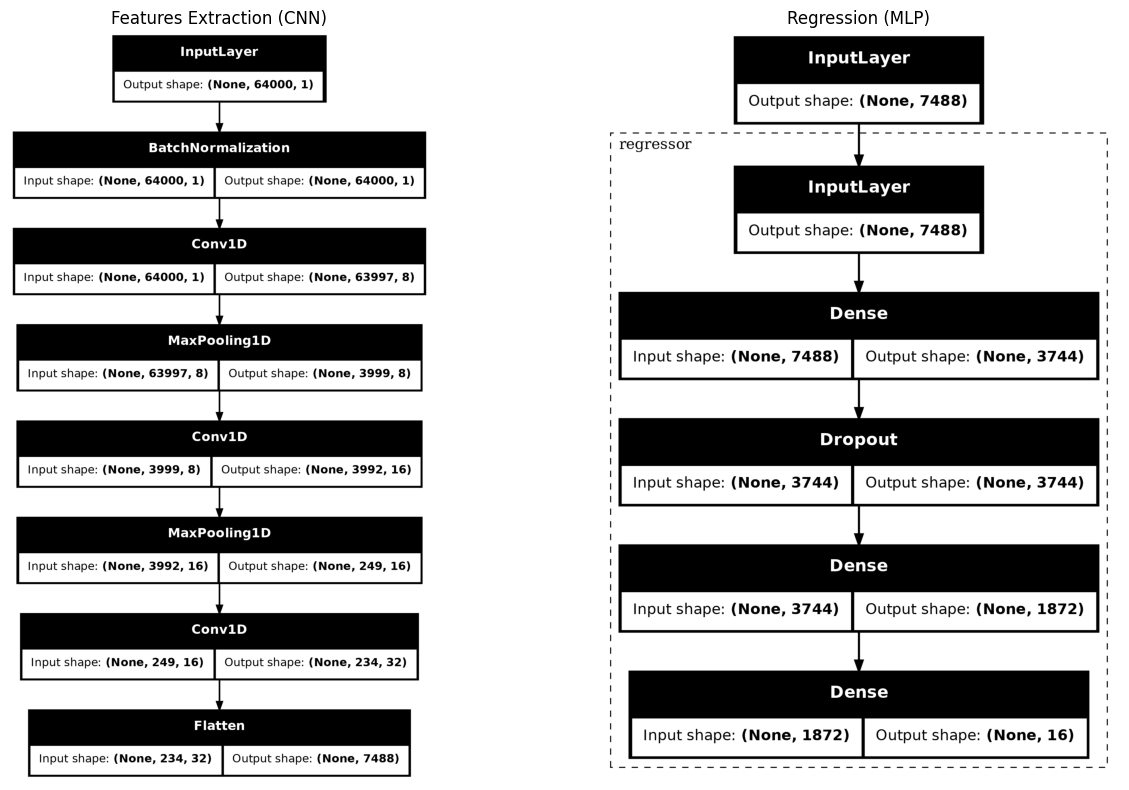

In [23]:
# 1) Gere as imagens
plot_model(features, to_file="projecao.png", show_shapes=True, rankdir="TB", dpi=200)
plot_model(regression,    to_file="regressao.png", show_shapes=True, expand_nested=True, rankdir="TB", dpi=200)

# 2) (Opcional) Exiba lado a lado no notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(mpimg.imread("projecao.png"));  axes[0].set_title("Features Extraction (CNN)"); axes[0].axis("off")
axes[1].imshow(mpimg.imread("regressao.png")); axes[1].set_title("Regression (MLP)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

In [24]:
# Callback para recuperar o melhor peso, e parar quando ficar três épocas sem melhora
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Treinando o modelo
history = model.fit(x, y_train_norm, epochs=200, validation_split = 0.2, callbacks=[callback])

Epoch 1/200


I0000 00:00:1759624536.977981   43350 service.cc:152] XLA service 0x7f7ae8005120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759624536.979070   43350 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-10-04 21:35:37.085414: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1759624537.363993   43350 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-10-04 21:35:40.302202: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=1,k3=0} for conv %cudnn-conv.8 = (f32[1,8,1,4]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,32,1,64000]{3,2,1,0} %bitcast.6722, f32[8,32,1,63997]{3,2,1,0} %bitcast.6729), window={size=1x63997}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_ta

 1/94 ━━━━━━━━━━━━━━━━━━━━ 11:25 7s/step - loss: 51.2081 - mae: 0.9074 - mse: 1.2841

I0000 00:00:1759624542.691412   43350 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 207ms/step - loss: 9.4466 - mae: 0.7583 - mse: 1.1636 - val_loss: 2.3852 - val_mae: 0.7078 - val_mse: 0.7996
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - loss: 1.6122 - mae: 0.6531 - mse: 0.7253 - val_loss: 1.1705 - val_mae: 0.6350 - val_mse: 0.7130
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - loss: 0.9953 - mae: 0.6310 - mse: 0.6942 - val_loss: 0.8766 - val_mae: 0.5969 - val_mse: 0.6860
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - loss: 0.8275 - mae: 0.6172 - mse: 0.6742 - val_loss: 0.7599 - val_mae: 0.5869 - val_mse: 0.6408
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - loss: 0.7648 - mae: 0.6064 - mse: 0.6589 - val_loss: 0.7333 - val_mae: 0.5744 - val_mse: 0.6298
Epoch 6/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - loss: 0.7389 - mae: 0.5978 - mse: 0.6478 - val_loss: 0.7083 - val_mae: 0.5845 - val_mse: 0.6241
Epoch 7/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - loss: 0.7199 - mae: 0.5912 - mse: 0.6378 - v

In [25]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,mse,val_loss,val_mae,val_mse,epoch
70,0.602907,0.526743,0.545032,0.621827,0.517079,0.561637,70
71,0.601406,0.525641,0.542252,0.636533,0.520494,0.568913,71
72,0.605446,0.525982,0.544554,0.620762,0.515503,0.565479,72
73,0.601740,0.524337,0.541330,0.624697,0.521619,0.568366,73
74,0.611486,0.527641,0.547872,0.624944,0.520362,0.563225,74


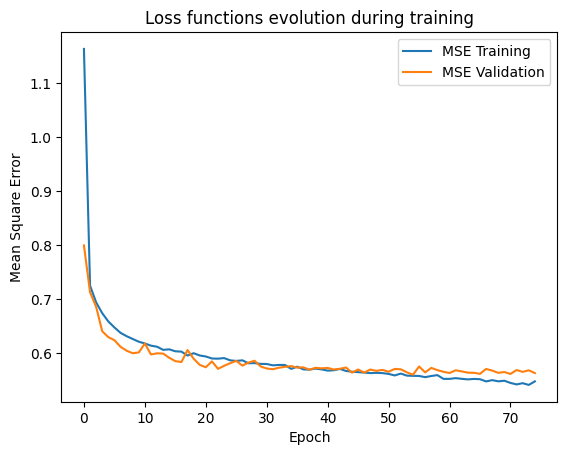

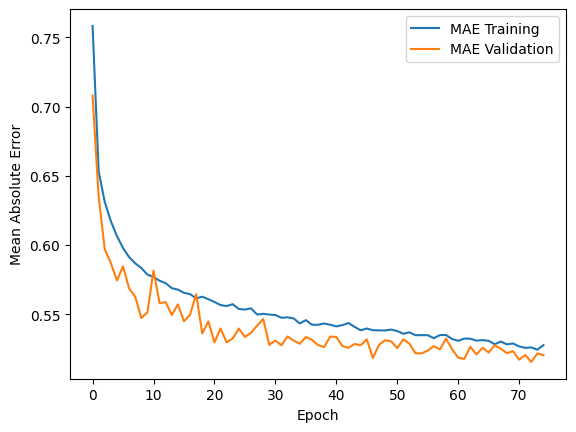

In [26]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure()
plt.title("Loss functions evolution during training")
plt.xlabel('Epoch')
plt.ylabel('Mean Square Error')
plt.plot(hist['epoch'], hist['mse'], label='MSE Training')
plt.plot(hist['epoch'], hist['val_mse'], label = 'MSE Validation')
plt.legend()

plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.plot(hist['epoch'], hist['mae'], label='MAE Training')
plt.plot(hist['epoch'], hist['val_mae'], label = 'MAE Validation')
plt.legend()

plt.show()

## Prevendo a amostra de teste

### Ajustando a base de teste

In [27]:
x_t = pd.DataFrame(test[0])
x_t.head()

,0
0,"[-3.0517578125e-05, 0.0, 0.0, 3.0517578125e-05..."
7,"[-3.0517578125e-05, 0.0, 6.103515625e-05, 0.00..."
16,"[-3.0517578125e-05, 0.0, 0.0, 0.0, 0.0, 3.0517..."
21,"[-3.0517578125e-05, 0.0, 0.0001220703125, 0.00..."
24,"[-3.0517578125e-05, 0.0, 0.0, 3.0517578125e-05..."


In [28]:
x_t = np.array(x_t[0].values.tolist())
x_t[0]

array([-3.05175781e-05,  0.00000000e+00,  0.00000000e+00, ...,
       -3.05175781e-04, -2.13623047e-04, -1.22070312e-04])

In [29]:
len(x_t[0])

64000

In [30]:
y_t = test.drop(columns=[0])
y_t.head()

,frequencia_base,frequency1,beta2,frequency2,beta3,frequency3,beta4,frequency4,beta5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,33.972,0.167,4.101,3.000,2.078,5.000,0.000,1.500,2.812,0.167,8.000,0.769,0.113,0.426,0.774,0.375
7,597.649,0.667,3.062,0.125,0.913,0.500,0.000,0.500,0.000,0.200,0.467,0.904,0.484,0.200,0.726,0.753
16,43.094,0.356,0.000,1.500,2.798,0.667,4.933,1.317,0.000,0.255,8.000,0.580,0.470,0.303,0.220,0.767
21,363.104,0.250,2.389,4.000,0.000,0.667,0.522,3.000,2.782,0.333,1.296,0.904,0.157,0.270,0.832,0.205
24,35.348,3.000,4.261,0.333,0.000,6.000,2.130,0.125,2.262,4.000,8.000,0.573,0.115,0.491,0.748,0.421


In [31]:
# Gravando x_t e y_t num arquivo .npy
np.save(f"{base_path}/x_test_big2.npy", x_t)
np.save(f"{base_path}/y_test_big2.npy", y_t)

### Chamando o modelo para predição

In [32]:
y_pred_norm = model.predict(x_t)

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


In [33]:
y_pred = scaler_y.inverse_transform(y_pred_norm)

In [34]:
y_pred = pd.DataFrame(y_pred)
y_pred.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,21.057653,1.746934,1.782403,3.534328,2.842510,2.792824,1.504558,2.843000,2.040940,2.351144,6.263576,0.664153,0.086921,0.357042,0.778289,0.380336
1,570.650391,1.288997,0.714494,1.271619,0.592733,1.178200,0.367999,0.784275,0.598068,1.509250,0.891034,0.673365,0.483065,0.290938,0.724966,0.696462
2,34.161324,1.588740,1.463545,2.176809,1.954761,1.790028,1.650495,1.786948,1.591101,2.544376,5.434439,0.713018,0.463116,0.332558,0.227416,0.619776
3,287.777893,1.441759,1.330536,1.324218,0.605905,1.365912,1.370770,1.542897,1.360450,1.747028,3.121464,0.684598,0.136814,0.302580,0.826159,0.241654
4,55.807869,1.627742,1.773420,2.498875,1.010202,4.324940,1.910292,3.054889,2.113024,2.737824,5.868417,0.657693,0.089392,0.395698,0.764808,0.433947


### Calculando erro de teste

In [35]:
mse = tf.keras.losses.MSE(y_t, y_pred).numpy().mean()
mae = tf.keras.losses.MAE(y_t, y_pred).numpy().mean()
rmse = np.sqrt(mse)

In [36]:
print(f"RMSE Test: {rmse}")
print(f"MSE Test: {mse}")
print(f"MAE Test: {mae}")

RMSE Test: 37.55125427246094
MSE Test: 1410.0968017578125
MAE Test: 6.487724781036377


### Salvando o modelo

In [37]:
model.save('model_conv_1_sec_v1_4.keras')

### Salvando o scaler

In [38]:
# Salvando o scaller_y
import joblib
joblib.dump(scaler_y, 'scaler_y_conv_1_sec_v1_4.save')

['scaler_y_conv_1_sec_v1_4.save']